# Desafio: Previsão de Custos de Frete

####Objetivo: Construir um modelo de Regressão Linear para prever a coluna custo_frete_real com base nas características da viagem.

In [26]:
# Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np

In [27]:
# Importando arquivo e gerando DataFrame
df = pd.read_csv('/content/base_operacoes_logistica.csv')
display(df)

,id_operacao,distancia_km,volume_transportado_ton,tipo_veiculo,dias_chuva_rota,valor_pedagios_brt,tempo_carregamento_horas,custo_frete_real,status_entrega
0,1,480.72,19.26,Truck,2,135.82,4.1,2915.42,Atrasado
1,2,1143.32,37.10,Truck,0,509.03,5.1,4875.97,Atrasado
2,3,891.79,53.65,Rodotrem,4,247.08,5.9,4635.51,No Prazo
3,4,738.46,46.61,Truck,2,552.09,2.4,4174.17,Atrasado
4,5,229.42,50.33,Truck,1,361.13,4.1,1848.29,Atrasado
...,...,...,...,...,...,...,...,...,...
995,996,155.32,42.85,Rodotrem,2,383.26,3.1,1412.19,No Prazo
996,997,1104.91,57.83,Truck,4,327.04,4.4,6321.80,Atrasado
997,998,207.34,13.45,Truck,0,533.13,1.4,1225.22,No Prazo
998,999,1142.77,12.85,Truck,0,573.88,5.3,4130.97,Atrasado


In [28]:
# Verificando tipos das colunas e detecção de nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_operacao               1000 non-null   int64  
 1   distancia_km              1000 non-null   float64
 2   volume_transportado_ton   1000 non-null   float64
 3   tipo_veiculo              1000 non-null   object 
 4   dias_chuva_rota           1000 non-null   int64  
 5   valor_pedagios_brt        1000 non-null   float64
 6   tempo_carregamento_horas  1000 non-null   float64
 7   custo_frete_real          1000 non-null   float64
 8   status_entrega            1000 non-null   object 
dtypes: float64(5), int64(2), object(2)
memory usage: 70.4+ KB


In [29]:
# Verificação estatística
df.describe()

,id_operacao,distancia_km,volume_transportado_ton,dias_chuva_rota,valor_pedagios_brt,tempo_carregamento_horas,custo_frete_real
count,1000.000000,1000.00000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,613.79504,35.35080,1.98900,315.736950,4.417700,3448.419490
std,288.819436,335.95799,14.60942,1.41947,160.935563,2.003225,1192.394698
min,1.000000,55.33000,10.16000,0.00000,50.100000,1.000000,800.000000
25%,250.750000,321.36750,22.05250,1.00000,177.460000,2.700000,2500.855000
50%,500.500000,621.33000,35.93500,2.00000,308.735000,4.400000,3406.245000
75%,750.250000,905.97000,48.02000,3.00000,458.500000,6.100000,4356.255000
max,1000.000000,1199.68000,59.97000,4.00000,598.690000,8.000000,6572.660000


In [30]:
# 1. Selecionando apenas variáveis numéricas
df_numerico = df[[
    'distancia_km',
    'volume_transportado_ton',
    'dias_chuva_rota',
    'valor_pedagios_brt',
    'tempo_carregamento_horas',
    'custo_frete_real'
]]

In [31]:
# 2. Definição das variáveis X e y
X = df_numerico.drop(columns=['custo_frete_real'])
y = df_numerico['custo_frete_real']

# 2.1 Montando modelo de treino
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size= 0.20, # Definido 20% da base p/ teste
    random_state= 42 # garantir corte aleatório seja sempre o mesmo
)

In [32]:
# 3. Definindo a variável do modelo
modelo = LinearRegression()

# 3.1 Treinando o modelo
modelo.fit(
    X_treino,
    y_treino
)

LinearRegression()

In [34]:
# 4. Avaliação do modelo
previsoes = modelo.predict(X_teste) #Prevendo custo apenas com variáveis da base teste

# 4.1 Calcular o Erro (MAE)
erro_meddio = mean_absolute_error(
    y_teste,
    previsoes
)

# 4.2 Exibindo resultado
print(f'O erro médio do moddelo é de R$ {erro_meddio:.2f}')

O erro médio do moddelo é de R$ 236.77


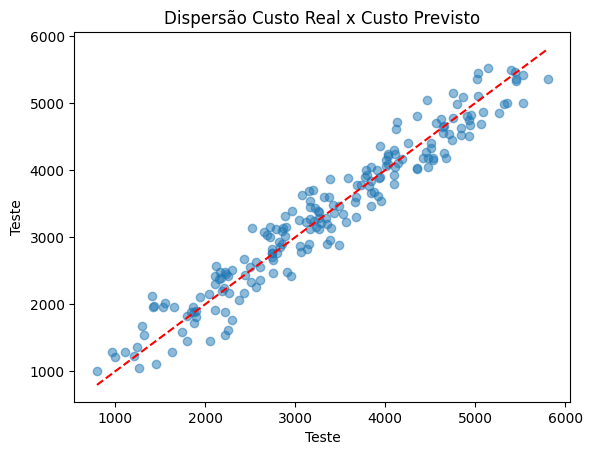

In [36]:
# 5. Visualizando os Resultados
plt.scatter(y_teste, previsoes, alpha=0.5)

# 5.1 Variáveis mínimo e máximo p/ reta
minimo = y_teste.min()
maximo = y_teste.max()
plt.plot([minimo, maximo], [minimo, maximo], color='red', linestyle='--')

# 5.2 Nomeando os eixos e título
plt.xlabel('Custo Real (R$)')
plt.ylabel('Custo Previsto (R$)')
plt.title('Dispersão Custo Real x Custo Previsto')
plt.show()